# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing?

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Olympia Sauerwein

**Date:** 9/2/26

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft      Manhattan   

  Property Type  Review Scores Rating (bin)        Room Type  Zipcode  Beds  \
0     Apartment                         NaN  Entire home/apt  11249.0   1.0   
1     Apartment                         NaN     Private room  11206.0   1.0   
2     Apartment                         NaN     Private room  10032.0   1.0   
3     Apartment                         NaN  Entire home/apt  10024.0   3.0   
4     Apartment                        95.0     Private room  10036.0   3.0   

   Number of Records  Number Of Reviews Price  Review Scores R

<Axes: >

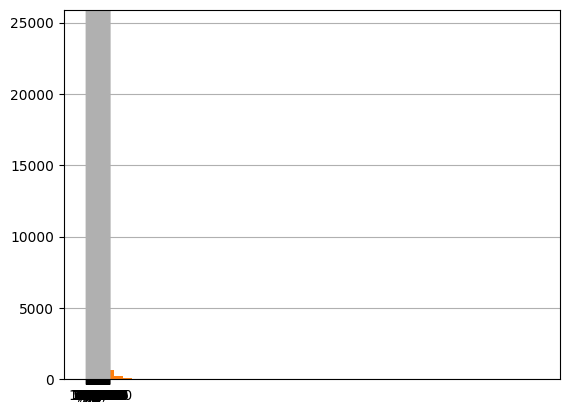

In [2]:
#QUESTION 1 PART 1
import numpy as np
import pandas as pd

# import the data
df_airbnb = pd.read_csv("/content/airbnb_hw.csv")

# view the data
print(df_airbnb.head())
price = 'Price'
print(df_airbnb[price].unique(), '\n')
print(df_airbnb[price].value_counts(), '\n')
df_airbnb[price].hist()

# get rid of the commas to clean
df_airbnb[price] = df_airbnb[price].str.replace(',', '', regex=True)

# convert to numeric so the price is represented as a number
df_airbnb[price] = pd.to_numeric(df_airbnb[price], errors='coerce')

# check that there are no missing values
df_airbnb['price_nan'] = df_airbnb[price].isnull()
print('Total missings:\n', sum(df_airbnb['price_nan']), '\n')

# generate histogram to confirm data
print('After coercion:\n', df_airbnb[price].describe(), '\n')
df_airbnb[price].hist(bins=50)

In [3]:
#QUESTION 1 PART 2

# import data
df_mnpolice = pd.read_csv("/content/mn_police_use_of_force.csv")

# view the data
var = 'subject_injury'
print(df_mnpolice[var].unique(), '\n')
print(df_mnpolice[var].value_counts(dropna=False), '\n')

# still missing 9848 answers!


[nan 'No' 'Yes'] 

subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64 



In [4]:
# confirm blank cells are noted as missing/nan
df_mnpolice['subject_injury_nan'] = df_mnpolice[var].isnull()
print('Total missing:\n', sum(df_mnpolice['subject_injury_nan']), '\n')

# cross-tabluate  subject_injury with force_type
ct = pd.crosstab(df_mnpolice['force_type'], df_mnpolice[var], dropna=False)
print(ct, '\n')

# it seems data is most likely to be missing when there is bodily force,
# chemical irritant, less lethal, maximal restrainst techniques, or tasers
# involved.

Total missing:
 9848 

subject_injury                 No   Yes   NaN
force_type                                   
Baton                           0     2     2
Bodily Force                 1093  1286  7051
Chemical Irritant             131    41  1421
Firearm                         2     0     0
Gun Point Display              33    44    27
Improvised Weapon              34    40    74
Less Lethal                     0     0    87
Less Lethal Projectile          1     2     0
Maximal Restraint Technique     0     0   170
Police K9 Bite                  2    44    31
Taser                         150   172   985 



In [5]:
# QUESTION 2

# import data
sharks = pd.read_excel('/content/drive/MyDrive/data/GSAF5.xls', sheet_name='Sheet1-GSAF')

# view the data
print("df.shape:")
print(sharks.shape, '\n')
print("df.dtypes:")
print(sharks.dtypes, '\n')
sharks.head()

df.shape:
(7117, 23) 

df.dtypes:
Date               object
Year              float64
Type               object
Country            object
State              object
Location           object
Activity           object
Name               object
Sex                object
Age                object
Injury             object
Fatal Y/N          object
Time               object
Species            object
Source             object
pdf                object
href formula       object
href               object
Case Number        object
Case Number.1      object
original order    float64
Unnamed: 21        object
Unnamed: 22        object
dtype: object 



,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columns after dropping empty ones: (7117, 21) 

count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64 

Attacks since 1940: (5581, 21) 



<Axes: >

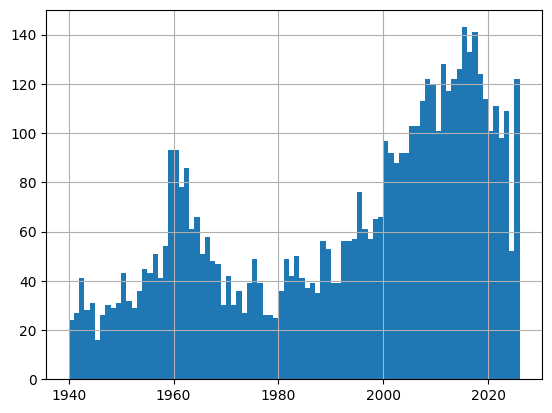

In [6]:
# remove columns that don't contain data (columns 21 and 22)
keep_cols = [c for c in sharks.columns if c not in ['Unnamed: 21', 'Unnamed: 22']]
sharks = sharks.loc[:, keep_cols]
print('Columns after dropping empty ones:', sharks.shape, '\n')

# check year variable
Year = 'Year'
print(sharks[Year].describe(), '\n')
#range technically starts at year 0 and spans until this year, 2026

# filter to attacks since 1940 and then print histogram
df_recent = sharks[sharks[Year] >= 1940]
print('Attacks since 1940:', df_recent.shape, '\n')
df_recent[Year].hist(bins=int(df_recent[Year].max() - df_recent[Year].min()))
# looks like shark attacks peaked in 1960 and then again in 2018; they have gone
# down since then until this year where they almost reached the peak in 2018.


In [7]:
# check age variable
Age = 'Age'
print('Before coercion:\n', sharks[Age].describe(), '\n')

Before coercion:
 count     4123
unique     252
top         16
freq        92
Name: Age, dtype: int64 



After coercion:
 count    3948.000000
mean       28.197315
std        14.697518
min         1.000000
25%        17.000000
50%        24.000000
75%        37.000000
max        87.000000
Name: Age, dtype: float64 

Total missing:
 3169 



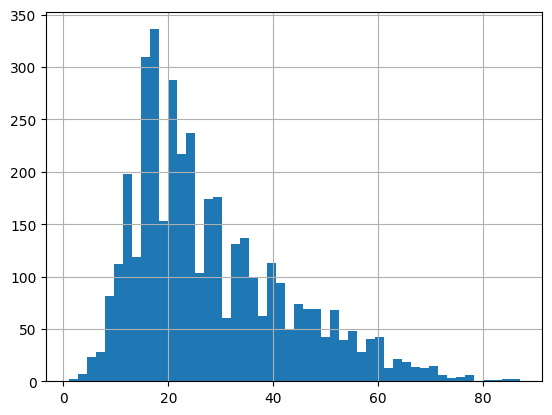

In [8]:
# clean age variable by converting to numeric
sharks[Age] = pd.to_numeric(sharks[Age], errors='coerce')
sharks['age_nan'] = sharks[Age].isnull()

# histrogram with results
print('After coercion:\n', sharks[Age].describe(), '\n')
sharks[Age].hist(bins=50)
print('Total missing:\n', sum(sharks['age_nan']), '\n')

In [9]:
# clean sex variable
Sex = 'Sex'
print(sharks[Sex].value_counts(dropna=False), '\n')

sharks[Sex] = sharks[Sex].replace({
    'M ': 'M', ' M': 'M', 'm': 'M',
    'F ': 'F',
    '?': np.nan, 'N': np.nan, '.': np.nan,
    'M F': np.nan, 'lli': np.nan, 'M x 2': np.nan
})
print(sharks[Sex].value_counts(dropna=False), '\n')

prop_male = sum(sharks[Sex] == 'M') / sharks.shape[0]
print('Proportion male:', round(prop_male, 3), '\n')

# 0.803 of people attacked by sharks are male.

Sex
M        5704
F         816
NaN       578
M           7
?           2
N           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
.           1
Name: count, dtype: int64 

Sex
M      5713
F       818
NaN     586
Name: count, dtype: int64 

Proportion male: 0.803 



In [10]:
# clean type of shark attack data by first identifying what is there
Type = 'Type'
print(sharks[Type].value_counts(dropna=False), '\n')

# replacing variations of unprovoked with the same name
sharks[Type] = sharks[Type].replace(['UNprovoked', 'unprovoked', 'unprovoked'],
                                    'Unprovoked')
# replacing variations of provoked with the same name
sharks[Type] = sharks[Type].replace(['provoked', ' Provoked'], 'Provoked')

# replacing other possibilities with unknown
sharks[Type] = sharks[Type].replace(
    ['Questionable', 'Watercraft', 'Sea Disaster', '?',
     'Unconfirmed', 'Unverified', 'Invalid', 'Under investigation', 'Boat', 'NaN'],
    'Unknown'
)

sharks[Type] = sharks[Type].fillna('Unknown')

# find proportion of unprovoked attacks
print(sharks[Type].value_counts(dropna=False), '\n')

prop_unprovoked = sum(sharks[Type] == 'Unprovoked') / sharks.shape[0]
print('Proportion unprovoked:', round(prop_unprovoked, 3), '\n')

# almost 74% of shark attacks are unprovoked!

Type
Unprovoked             5261
Provoked                647
Invalid                 552
Watercraft              355
Sea Disaster            242
Questionable             27
NaN                      18
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
Unconfirmed               1
?                         1
Unverified                1
Under investigation       1
Name: count, dtype: int64 

Type
Unprovoked    5263
Unknown       1205
Provoked       649
Name: count, dtype: int64 

Proportion unprovoked: 0.739 



Commit #1: dba8544a47c651ccf59e5d3a3db128445c3869fb


 (not sure if this is correct--finished the assignment earlier on Colab, so I couldn't find the commit until figuring out how to upload it on github)

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** dba8544
- **AI tool and model used:** Claude - Sonnet 5

### *Prompts used

1. "How is this?" with file attached


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1.1 — Airbnb price
The comma-stripping + to_numeric(errors='coerce') approach is the right idea for the "675 → 1,112" issue the hint points at. One thing worth double-checking before you report your missing count: many Airbnb price columns also carry a leading $ (e.g. "$1,112"), and your code only strips commas. If a $ is present, to_numeric will silently coerce every row to NaN, and your missing count will look enormous without you noticing why. Worth doing a quick df_airbnb[price].str.contains('\$').any() or just eyeballing .unique() before the clean to confirm what characters you're actually dealing with.

Q1.2 — MN police subject_injury
This part explores the missingness well (unique values, count, cross-tab with force_type), but it stops short of actually cleaning the variable. The prompt asks you to end up with a variable that only takes Yes/No — right now you've quantified the 9,848 missing values and cross-tabbed them, but nothing replaces or recodes the NAs. You'll want to make an explicit decision (e.g., "no injury recorded" → No, or leave as a third category and justify why) and actually apply it with .fillna(...) or similar. Your observation about missingness clustering around bodily force/chemical irritant/tasers is a nice catch and a good thing to reference when justifying that decision.

Q2.2 — Dropping empty columns
Hardcoding ['Unnamed: 21', 'Unnamed: 22'] works for this specific file, but it's brittle — if the source spreadsheet shifts by even one column next time you re-download it, this silently drops the wrong columns (or none). A more robust version: sharks.dropna(axis=1, how='all').

Q2.3 — Year
You print .describe() and note the min is 0, which is a good catch (likely a placeholder for "unknown year" entries rather than a real attack in year 0). Since you filter to >= 1940 right after, it doesn't bite you here, but it's worth a one-line comment noting that year-0 rows exist and are being excluded by the filter, not treated as data errors separately.

Q2.4 — Age
to_numeric(errors='coerce') is a reasonable quick clean, but it'll null out anything not already a clean number — entries like "20s", "teen", or "mid-30s" (common in this dataset) get thrown away entirely rather than partially recovered. Fine for a first pass, but worth flagging in your writeup as a limitation, or optionally following up with a regex digit-extraction if you want to recover more of those.

Q2.5 — Sex / proportion male
Your cleaning of typos and stray values ('m', 'M ', '?', etc.) is solid. But look at the denominator here:

python
prop_male = sum(sharks[Sex] == 'M') / sharks.shape[0]

This divides by all rows, including the ones you just set to NaN and any other non-M/F rows. So 0.803 is "share of all shark attack records that are male," not "share of victims with known sex who are male" — those two numbers can differ meaningfully if there's a lot of missingness. If the question means the latter (which is the more common framing), you'd want sum(sharks[Sex]=='M') / sharks[Sex].isin(['M','F']).sum().

Q2.6 — Type
Nicely done — collapsing to three categories then fillna('Unknown') means every row is accounted for, so dividing by sharks.shape[0] is correct here (unlike Q2.5). One tiny nit: ['UNprovoked', 'unprovoked', 'unprovoked'] lists 'unprovoked' twice — harmless, just redundant.

Overall: Phase 1 is mostly complete and your reasoning comments are genuinely helpful for a grader (or for future-you). The two things I'd fix before calling it done are the incomplete subject_injury cleaning and the price $-sign check; the age/sex-denominator points are more "worth a caveat in your writeup" than bugs. Phase 2 (AI-assisted revision) is still all placeholder text — nothing filled in yet.


### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | modify | some due to clarity, one comment reminding of final step of question |


### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125' '175' '40' '89' '95' '99' '499'
 '120' '79' '110' '180' '143' '230' '350' '135' '85' '60' '70' '55' '44'
 '200' '165' '115' '74' '84' '129' '50' '185' '80' '190' '140' '45' '65'
 '225' '600' '109' '1,990' '73' '240' '72' '105' '155' '160' '42' '132'
 '117' '295' '280' '159' '107' '69' '239' '220' '399' '130' '375' '585'
 '275' '139' '260' '35' '133' '300' '289' '179' '98' '195' '29' '27' '39'
 '249' '192' '142' '169' '1,000' '131' '138' '113' '122' '329' '101' '475'
 '238' '272' '308' '126' '235' '315' '248' '128' '56' '207' '450' '215'
 '210' '385' '445' '136' '247' '118' '77' '76' '92' '198' '205' '299'
 '222' '245' '104' '153' '349' '114' '320' '292' '226' '420' '500' '325'
 '307' '78' '265' '108' '123' '189' '32' '58' '86' '219' '800' '335' '63'
 '229' '425' '67' '87' '1,200' '158' '650' '234' '310' '695' '400' '166'
 '119' '62' '168' '340' '479' '43' '395' '144' '52' 

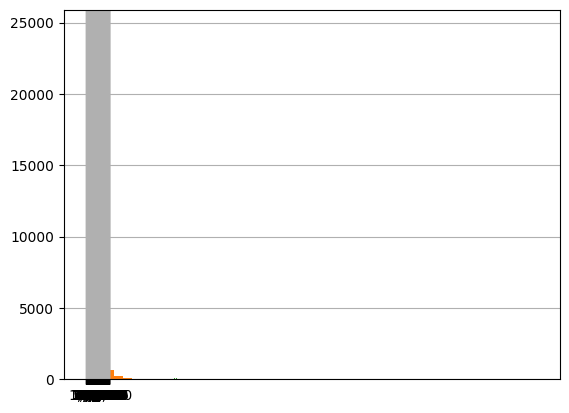

In [11]:
import numpy as np
import pandas as pd

# ===================== QUESTION 1 PART 1 =====================
df_airbnb = pd.read_csv("/content/airbnb_hw.csv")

price = 'Price'
print(df_airbnb[price].unique(), '\n')
print(df_airbnb[price].value_counts(), '\n')
df_airbnb[price].hist()

# get rid of the commas to clean
df_airbnb[price] = df_airbnb[price].str.replace(',', '', regex=True)

# convert to numeric so the price is represented as a number
df_airbnb[price] = pd.to_numeric(df_airbnb[price], errors='coerce')

# check that there are no missing values
df_airbnb['price_nan'] = df_airbnb[price].isnull()
print('Total missings:\n', sum(df_airbnb['price_nan']), '\n')

print('After coercion:\n', df_airbnb[price].describe(), '\n')
df_airbnb[price].hist(bins=50)


# ===================== QUESTION 1 PART 2 =====================
df_mnpolice = pd.read_csv("/content/mn_police_use_of_force.csv")

var = 'subject_injury'
print(df_mnpolice[var].unique(), '\n')
print(df_mnpolice[var].value_counts(dropna=False), '\n')

# confirm blank cells are noted as missing/nan
df_mnpolice['subject_injury_nan'] = df_mnpolice[var].isnull()
print('Total missing:\n', sum(df_mnpolice['subject_injury_nan']), '\n')

# cross-tabulate subject_injury with force_type (before cleaning)
ct = pd.crosstab(df_mnpolice['force_type'], df_mnpolice[var], dropna=False)
print(ct, '\n')

# it seems data is most likely to be missing when there is bodily force,
# chemical irritant, less lethal, maximal restraint techniques, or tasers
# involved.

# CLEAN subject_injury: this field looks like affirmative-only reporting
# (injury is logged as "Yes" when it happens; nothing is written down
# otherwise), so a blank/NaN most likely means "no injury was reported"
# rather than "unknown." We fill missing values with 'No' on that basis,
# and keep the subject_injury_nan flag above so this assumption is
# reversible if it turns out to be wrong.
df_mnpolice[var] = df_mnpolice[var].fillna('No')
print(df_mnpolice[var].value_counts(dropna=False), '\n')

# re-run the cross-tab now that subject_injury is fully Yes/No
ct_clean = pd.crosstab(df_mnpolice['force_type'], df_mnpolice[var], dropna=False)
print(ct_clean, '\n')


# ===================== QUESTION 2 =====================
sharks = pd.read_excel('/content/drive/MyDrive/data/GSAF5.xls', sheet_name='Sheet1-GSAF')

print("df.shape:")
print(sharks.shape, '\n')
print("df.dtypes:")
print(sharks.dtypes, '\n')
sharks.head()

# remove columns that don't contain any data at all
sharks = sharks.dropna(axis=1, how='all')
print('Columns after dropping empty ones:', sharks.shape, '\n')

# check year variable
Year = 'Year'
print(sharks[Year].describe(), '\n')
#range technically starts at year 0 and spans until this year, 2026

# filter to attacks since 1940 and then print histogram
df_recent = sharks[sharks[Year] >= 1940]
print('Attacks since 1940:', df_recent.shape, '\n')
df_recent[Year].hist(bins=int(df_recent[Year].max() - df_recent[Year].min()))
# looks like shark attacks peaked in 1960 and then again in 2018; they have gone
# down since then until this year where they almost reached the peak in 2018.

# check age variable
Age = 'Age'
print('Before coercion:\n', sharks[Age].describe(), '\n')

# clean age variable by converting to numeric
sharks[Age] = pd.to_numeric(sharks[Age], errors='coerce')
sharks['age_nan'] = sharks[Age].isnull()

print('After coercion:\n', sharks[Age].describe(), '\n')
sharks[Age].hist(bins=50)
print('Total missing:\n', sum(sharks['age_nan']), '\n')

# clean sex variable
Sex = 'Sex'
print(sharks[Sex].value_counts(dropna=False), '\n')

sharks[Sex] = sharks[Sex].replace({
    'M ': 'M', ' M': 'M', 'm': 'M',
    'F ': 'F',
    '?': np.nan, 'N': np.nan, '.': np.nan,
    'M F': np.nan, 'lli': np.nan, 'M x 2': np.nan
})
print(sharks[Sex].value_counts(dropna=False), '\n')

# denominator is rows with a known M/F value, so missing/unusable
# entries aren't silently counted as "not male"
known_sex = sharks[Sex].isin(['M', 'F'])
prop_male = sum(sharks[Sex] == 'M') / sum(known_sex)
print('Proportion male (of known sex):', round(prop_male, 3), '\n')

# clean type of shark attack data by first identifying what is there
Type = 'Type'
print(sharks[Type].value_counts(dropna=False), '\n')

# replacing variations of unprovoked with the same name
sharks[Type] = sharks[Type].replace(['UNprovoked', 'unprovoked'], 'Unprovoked')
# replacing variations of provoked with the same name
sharks[Type] = sharks[Type].replace(['provoked', ' Provoked'], 'Provoked')

# replacing other possibilities with unknown
sharks[Type] = sharks[Type].replace(
    ['Questionable', 'Watercraft', 'Sea Disaster', '?',
     'Unconfirmed', 'Unverified', 'Invalid', 'Under investigation', 'Boat', 'NaN'],
    'Unknown'
)

sharks[Type] = sharks[Type].fillna('Unknown')

print(sharks[Type].value_counts(dropna=False), '\n')

prop_unprovoked = sum(sharks[Type] == 'Unprovoked') / sharks.shape[0]
print('Proportion unprovoked:', round(prop_unprovoked, 3), '\n')

# almost 74% of shark attacks are unprovoked!

### *Reflection on AI assistance
In your own words without generative AI.

In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.

Overall, AI only made a couple super important changes. Its most important was unfortunately something that I should easily catch for Q1.2 by revising my work. Its suggestion in Q2.5 was also valuable; while it isn't explicity written in the guidelines, it makes a lot of sense that the proportions should not factor in NaN rows, even if there are few, this is an unneccessary confounding variable. The remainder of its suggestions were useful and as far as I know accurate, but not 100% necessary for this particular assignment; however, it was helpful to see what I should look out for in the future and how I might make my work more robust. For example, its suggestion on Q1.1 to check for $ is a great catch, as most of the time data involving money will not yet be cleaned and therefore may have currency signs. The other key suggestion to note for the future relates to Q2.2, in which I could've used code which is sturdier to drop empty columns, which would be especially important when I work with and change the format of the CSV.